# 04 - Visualizaciones e Informe Final

Genera gráficas, tablas de resumen y reportes desde `data/output/resultados_anomalias.csv`.

**Entrada**: `data/output/resultados_anomalias.csv`  
**Salidas**:
- Gráficas PNG en `data/output/`
- Informe HTML y CSV en `data/output/`
- Recomendaciones para README y video

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Config paths
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.append(str(ROOT))

DATA_DIR = ROOT / 'data' / 'output'
RESULTADOS_FILE = DATA_DIR / 'resultados_anomalias.csv'

# Cargar resultados del detector de anomalías
if not RESULTADOS_FILE.exists():
    raise FileNotFoundError(f'No se encontró {RESULTADOS_FILE}. Ejecuta los notebooks 01, 02 y 03 primero.')

df = pd.read_csv(RESULTADOS_FILE)

print('=== Datos cargados ===')
print(f'Formularios: {len(df)}')
print(f'Columnas: {len(df.columns)}')
print(f'\nResumen de anomalías:')
print(f'  - Sospechosas por reglas: {df["sospechosa_reglas"].sum()}')
print(f'  - Sospechosas por z-score: {df["sospechosa_zscore"].sum()}')
print(f'  - Sospechosas final: {df["sospechosa_final"].sum()}')
print(f'\nPrimeras 5 filas:')
print(df[['form_id', 'sospechosa_reglas', 'sospechosa_zscore', 'max_zscore', 'motivo_alerta']].head())

=== Datos cargados ===
Formularios: 17
Columnas: 20

Resumen de anomalías:
  - Sospechosas por reglas: 17
  - Sospechosas por z-score: 3
  - Sospechosas final: 17

Primeras 5 filas:
   form_id  sospechosa_reglas  sospechosa_zscore  max_zscore  \
0  E14_001               True              False    0.667760   
1  E14_002               True              False    0.840057   
2  E14_003               True              False    0.840057   
3  E14_004               True               True    3.448768   
4  E14_005               True              False    2.190890   

                                   motivo_alerta  
0                               total_incorrecto  
1                               total_incorrecto  
2                               total_incorrecto  
3  total_incorrecto | ocr_invalido | zscore=3.45  
4                                   ocr_invalido  


## 1. Gráfica: Resumen de Anomalías Detectadas

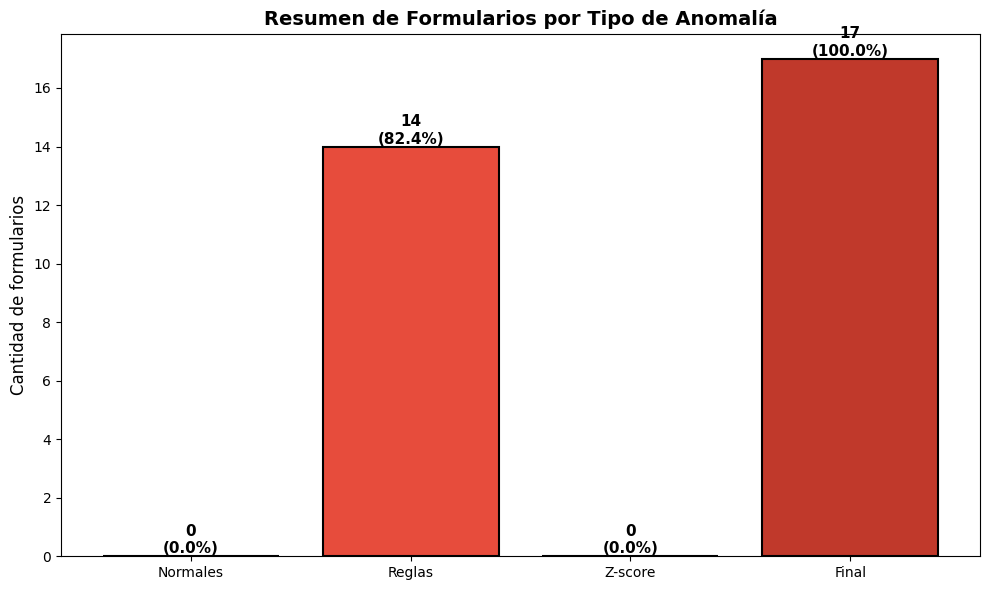

✓ Guardado: g01_resumen_anomalias.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

categorias = ['Normales', 'Reglas', 'Z-score', 'Final']
normales = len(df) - df['sospechosa_final'].sum()
por_reglas = (df['sospechosa_reglas'] & ~df['sospechosa_zscore']).sum()
por_zscore = (~df['sospechosa_reglas'] & df['sospechosa_zscore']).sum()
ambas = (df['sospechosa_reglas'] & df['sospechosa_zscore']).sum()

valores = [normales, por_reglas, por_zscore, df['sospechosa_final'].sum()]
colores = ['#2ecc71', '#e74c3c', '#f39c12', '#c0392b']

barras = ax.bar(categorias, valores, color=colores, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Cantidad de formularios', fontsize=12)
ax.set_title('Resumen de Formularios por Tipo de Anomalía', fontsize=14, fontweight='bold')

for i, (barra, val) in enumerate(zip(barras, valores)):
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., altura,
            f'{int(val)}\n({100*val/len(df):.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(DATA_DIR / 'g01_resumen_anomalias.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Guardado: g01_resumen_anomalias.png')

## 2. Gráfica: Distribución de Z-Scores

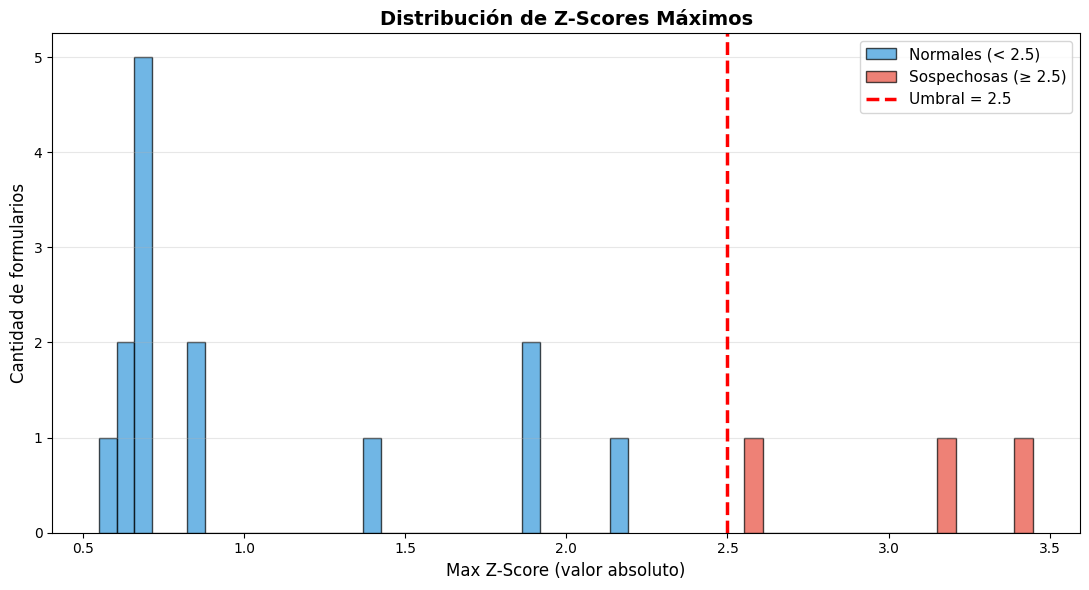

✓ Guardado: g02_distribucion_zscore.png


In [4]:
fig, ax = plt.subplots(figsize=(11, 6))

UMBRAL_Z = 2.5
normales = df[~df['sospechosa_zscore']]['max_zscore']
sospechosas = df[df['sospechosa_zscore']]['max_zscore']

ax.hist(normales, bins=30, alpha=0.7, label=f'Normales (< {UMBRAL_Z})', color='#3498db', edgecolor='black')
ax.hist(sospechosas, bins=15, alpha=0.7, label=f'Sospechosas (≥ {UMBRAL_Z})', color='#e74c3c', edgecolor='black')
ax.axvline(UMBRAL_Z, color='red', linestyle='--', linewidth=2.5, label=f'Umbral = {UMBRAL_Z}')

ax.set_xlabel('Max Z-Score (valor absoluto)', fontsize=12)
ax.set_ylabel('Cantidad de formularios', fontsize=12)
ax.set_title('Distribución de Z-Scores Máximos', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'g02_distribucion_zscore.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Guardado: g02_distribucion_zscore.png')

## 3. Gráfica: Tipos de Reglas Violadas

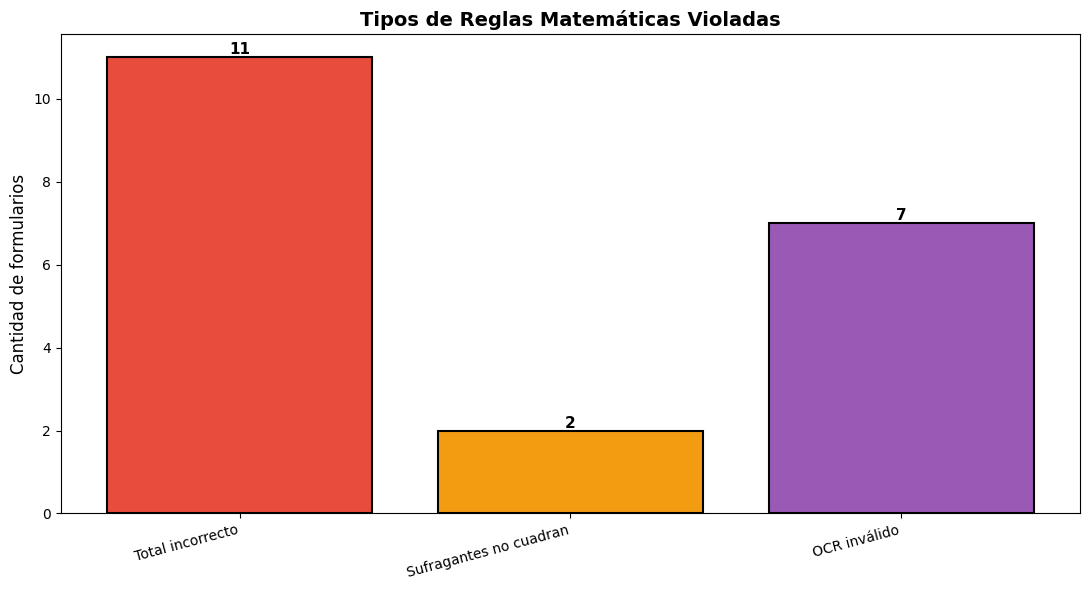

✓ Guardado: g03_tipos_reglas.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 6))

cols_reglas = ['alerta_total', 'alerta_sufragantes', 'alerta_ocr_invalido']
etiquetas = ['Total incorrecto', 'Sufragantes no cuadran', 'OCR inválido']

conteos = [df[col].sum() if col in df.columns else 0 for col in cols_reglas]
colores_reglas = ['#e74c3c', '#f39c12', '#9b59b6']

barras = ax.bar(etiquetas, conteos, color=colores_reglas, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Cantidad de formularios', fontsize=12)
ax.set_title('Tipos de Reglas Matemáticas Violadas', fontsize=14, fontweight='bold')

for barra, val in zip(barras, conteos):
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., altura,
            f'{int(val)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(DATA_DIR / 'g03_tipos_reglas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Guardado: g03_tipos_reglas.png')

## 4. Tabla: Formularios Sospechosos Detallados

In [6]:
df_sospechosas = df[df['sospechosa_final']].copy()
df_sospechosas = df_sospechosas.sort_values('max_zscore', ascending=False)

cols_tabla = ['form_id', 'sospechosa_reglas', 'sospechosa_zscore', 'max_zscore', 'motivo_alerta']
cols_tabla_presentes = [c for c in cols_tabla if c in df_sospechosas.columns]

print(f'\n=== FORMULARIOS SOSPECHOSOS ({len(df_sospechosas)}/{len(df)}) ===\n')
print(df_sospechosas[cols_tabla_presentes].to_string(index=False))

# Exportar tabla de sospechosas
df_sospechosas[cols_tabla_presentes].to_csv(DATA_DIR / 'informe_sospechosas.csv', index=False)
print(f'\n✓ Exportado: informe_sospechosas.csv')


=== FORMULARIOS SOSPECHOSOS (17/17) ===

form_id  sospechosa_reglas  sospechosa_zscore  max_zscore                                 motivo_alerta
E14_004               True               True    3.448768 total_incorrecto | ocr_invalido | zscore=3.45
E14_017               True               True    3.174352                    ocr_invalido | zscore=3.17
E14_007               True               True    2.551155                total_incorrecto | zscore=2.55
E14_005               True              False    2.190890                                  ocr_invalido
E14_008               True              False    1.915307                              total_incorrecto
E14_015               True              False    1.908545                              total_incorrecto
E14_013               True              False    1.381420         sufragantes_no_cuadran | ocr_invalido
E14_003               True              False    0.840057                              total_incorrecto
E14_002               

## 5. Resumen Estadístico e Informe Final

In [9]:
print('\n' + '='*70)
print('INFORME FINAL - ANÁLISIS DE ANOMALÍAS EN FORMULARIOS E14'.center(70))
print('='*70 + '\n')

print(f'Total de formularios procesados: {len(df)}')
print(f'Fecha de análisis: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}\n')

print('RESULTADOS:')
print('-' * 70)
print(f'  Formularios normales:           {len(df) - df["sospechosa_final"].sum():3d}  ({100*(len(df) - df["sospechosa_final"].sum())/len(df):.1f}%)')
print(f'  Sospechosos por reglas:        {(df["sospechosa_reglas"] & ~df["sospechosa_zscore"]).sum():3d}  ({100*(df["sospechosa_reglas"] & ~df["sospechosa_zscore"]).sum()/len(df):.1f}%)')
print(f'  Sospechosos por z-score:       {(~df["sospechosa_reglas"] & df["sospechosa_zscore"]).sum():3d}  ({100*(~df["sospechosa_reglas"] & df["sospechosa_zscore"]).sum()/len(df):.1f}%)')
print(f'  Sospechosos por ambos:         {(df["sospechosa_reglas"] & df["sospechosa_zscore"]).sum():3d}  ({100*(df["sospechosa_reglas"] & df["sospechosa_zscore"]).sum()/len(df):.1f}%)')
print(f'  TOTAL SOSPECHOSOS:            {df["sospechosa_final"].sum():3d}  ({100*df["sospechosa_final"].sum()/len(df):.1f}%)')

print('\nANÁLISIS DE REGLAS MATEMÁTICAS:')
print('-' * 70)
if 'alerta_total' in df.columns:
    print(f'  • Total incorrecto (suma detalle ≠ total):     {df["alerta_total"].sum():3d}')
if 'alerta_sufragantes' in df.columns:
    print(f'  • Sufragantes no cuadran (urna + incinerados): {df["alerta_sufragantes"].sum():3d}')
if 'alerta_ocr_invalido' in df.columns:
    print(f'  • OCR inválido (campos clave ilegibles):       {df["alerta_ocr_invalido"].sum():3d}')

print('\nESTADÍSTICAS DE Z-SCORE:')
print('-' * 70)
print(f'  • Máximo z-score en dataset:   {df["max_zscore"].max():.2f}')
print(f'  • Media de z-scores:           {df["max_zscore"].mean():.2f}')
print(f'  • Mediana de z-scores:         {df["max_zscore"].median():.2f}')
print(f'  • Desv. estándar:              {df["max_zscore"].std():.2f}')

print('\n' + '='*70 + '\n')

# Crear resumen para README
resumen_readme = f"""
## Resultados del Análisis de Anomalías

- **Total de formularios**: {len(df)}
- **Formularios sospechosos**: {df['sospechosa_final'].sum()} ({100*df['sospechosa_final'].sum()/len(df):.1f}%)
  - Por reglas matemáticas: {(df['sospechosa_reglas'] & ~df['sospechosa_zscore']).sum()}
  - Por z-score estadístico: {(~df['sospechosa_reglas'] & df['sospechosa_zscore']).sum()}
  - Por ambos métodos: {(df['sospechosa_reglas'] & df['sospechosa_zscore']).sum()}

### Violaciones de Reglas Detectadas
- Total incorrecto: {df.get('alerta_total', pd.Series()).sum() if 'alerta_total' in df.columns else 0}
- Sufragantes no cuadran: {df.get('alerta_sufragantes', pd.Series()).sum() if 'alerta_sufragantes' in df.columns else 0}
- OCR inválido: {df.get('alerta_ocr_invalido', pd.Series()).sum() if 'alerta_ocr_invalido' in df.columns else 0}

### Salidas Generadas
- `data/output/g01_resumen_anomalias.png` - Gráfica resumen
- `data/output/g02_distribucion_zscore.png` - Distribución de z-scores
- `data/output/g03_tipos_reglas.png` - Tipos de reglas violadas
- `data/output/informe_sospechosas.csv` - Detalle de formularios sospechosos
"""

with open(ROOT / 'INFORME_ANOMALIAS.md', 'w', encoding='utf-8') as f:
    f.write(resumen_readme)

print('Informe guardado en: INFORME_ANOMALIAS.md')


       INFORME FINAL - ANÁLISIS DE ANOMALÍAS EN FORMULARIOS E14       

Total de formularios procesados: 17
Fecha de análisis: 2026-06-03 11:37:48

RESULTADOS:
----------------------------------------------------------------------
  Formularios normales:             0  (0.0%)
  Sospechosos por reglas:         14  (82.4%)
  Sospechosos por z-score:         0  (0.0%)
  Sospechosos por ambos:           3  (17.6%)
  TOTAL SOSPECHOSOS:             17  (100.0%)

ANÁLISIS DE REGLAS MATEMÁTICAS:
----------------------------------------------------------------------
  • Total incorrecto (suma detalle ≠ total):      11
  • Sufragantes no cuadran (urna + incinerados):   2
  • OCR inválido (campos clave ilegibles):         7

ESTADÍSTICAS DE Z-SCORE:
----------------------------------------------------------------------
  • Máximo z-score en dataset:   3.45
  • Media de z-scores:           1.38
  • Mediana de z-scores:         0.84
  • Desv. estándar:              0.97


Informe guardado en: INFO